# 51 — PDB / AFDB P2Rank: best-vs-worst scatter, within "correct" only

**Scoped exploration, same spirit as
[48_scatter_color_exploration.ipynb](48_scatter_color_exploration.ipynb)** but for the P2Rank
predicted-pocket family (nb49/nb50), and one restriction narrower: every plot here is drawn **only
from pockets that already pass the standard correctness test** (`DCA ≤ 4 Å or DCC ≤ 4 Å`). The
question isn't "does a wrong prediction hurt the score" (nb50 already answered that) — it's **"among
predictions P2Rank got right, does *how* right it got them still matter?"**

Four metrics, each split into a "good" and "bad" sub-bin *within* the correct-only population:

| metric | direction | good | bad |
|---|---|---|---|
| DCA (Å) | lower = better | `< good_thresh` | `> bad_thresh` |
| DCC (Å) | lower = better | `< good_thresh` | `> bad_thresh` |
| Residue recall | higher = better | `> good_thresh` | `< bad_thresh` |
| Residue IoU | higher = better | `> good_thresh` | `< bad_thresh` |

Thresholds are function arguments, not constants — the point of §4 is to actually try more than one
value per metric and see whether the picture changes. Colour/marker convention is nb48's winner:
**dark shade of the condition colour = good, full condition colour + triangle marker = bad** (dark
recedes, the triangle+full-colour combo is what read clearest for the sparse group in nb48).

In [1]:
from __future__ import annotations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy import stats

PROJ = Path.cwd().parent / 'DATA' / 'drugclip'
POOLED = PROJ / 'RESULTS/p2rank_patches_pooled'
FIG_DIR = PROJ / 'RESULTS/p2rank_scatter_threshold_exploration/figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

CONDITIONS = [
    {
        'key': 'pdb_p2rank', 'name': 'PDB P2Rank', 'color': '#E377C2',
        'path': POOLED / 'pdb_p2rank_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_pdb_p2rank',
    },
    {
        'key': 'afdb_p2rank', 'name': 'AFDB P2Rank', 'color': '#D62728',
        'path': POOLED / 'afdb_p2rank_vs_exp_scores_pooled_dedup.tsv',
        'score_col': 'score_afdb_p2rank',
    },
]

SCORE_LIM   = (-0.55, 0.95)
SCORE_TICKS = np.arange(-0.4, 0.81, 0.2)

METRIC_INFO = {
    'dca':    {'label': 'DCA (Å)',           'higher_is_better': False},
    'dcc':    {'label': 'DCC (Å)',           'higher_is_better': False},
    'recall': {'label': 'Residue recall',    'higher_is_better': True},
    'iou':    {'label': 'Residue Intersection over Union', 'higher_is_better': True},
}

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10,
                      'axes.labelsize': 12, 'xtick.labelsize': 12, 'ytick.labelsize': 12})


def square(fig):
    for ax in fig.axes:
        ax.set_box_aspect(1)
    return fig


def darken(hex_color, amount=0.45):
    c = np.array(mcolors.to_rgb(hex_color))
    return mcolors.to_hex(c * (1 - amount))


def save_fig(fig, name, save, dpi):
    if save:
        fig.savefig(FIG_DIR / f'{name}.png', dpi=dpi, bbox_inches='tight')

## Load + restrict to "correct" (DCA ≤ 4 Å or DCC ≤ 4 Å)

In [2]:
for c in CONDITIONS:
    df = pd.read_csv(c['path'], sep='\t')
    n_total = len(df)
    correct = (df['dca'] <= 4) | (df['dcc'] <= 4)
    c['df'] = df[correct].copy()
    print(f"{c['name']:<12s}  correct: {correct.sum():,} / {n_total:,} ({correct.mean()*100:.1f}%)")

PDB P2Rank    correct: 13,348 / 15,328 (87.1%)
AFDB P2Rank   correct: 8,353 / 9,831 (85.0%)


## Plot function

`good_thresh` / `bad_thresh` are plain arguments — call it again with different numbers to see the
threshold's effect directly (§4 does exactly that).

In [3]:
def plot_metric_scatter(c, metric_col, good_thresh, bad_thresh, save=True, dpi=600):
    df, color, name, score_col = c['df'], c['color'], c['name'], c['score_col']
    info = METRIC_INFO[metric_col]
    label, higher_is_better = info['label'], info['higher_is_better']
    good_c, bad_c = darken(color), color
    print(f'{name} — {label} within correct only (n={len(df):,})')

    if higher_is_better:
        good_mask = df[metric_col] > good_thresh
        bad_mask  = df[metric_col] < bad_thresh
        good_desc, bad_desc = f'>{good_thresh}', f'<{bad_thresh}'
    else:
        good_mask = df[metric_col] < good_thresh
        bad_mask  = df[metric_col] > bad_thresh
        good_desc, bad_desc = f'<{good_thresh}', f'>{bad_thresh}'

    n_good, n_bad = good_mask.sum(), bad_mask.sum()
    series = [
        (good_mask, good_c, 'o', good_desc, n_good),
        (bad_mask,  bad_c,  '^', bad_desc,  n_bad),
    ]
    # Whichever group is sparser gets drawn last (on top) and rendered larger —
    # otherwise a small group (e.g. 30 points) is invisible underneath a 4,000-point one,
    # regardless of which of good/bad happens to be the sparse side.
    series.sort(key=lambda s: -s[4])

    fig, ax = plt.subplots(figsize=(6, 6))
    for zorder, (mask, col, marker, desc, n) in enumerate(series):
        sub = df[mask]
        if len(sub) < 5:
            continue
        sparse = n < 0.15 * len(df)
        size = 16 if sparse else 6
        r, _ = stats.pearsonr(sub['score_exp'], sub[score_col])
        ax.scatter(sub['score_exp'], sub[score_col], s=size, alpha=1.0, color=col, marker=marker,
                   edgecolors='black' if marker == '^' or sparse else 'none', linewidths=0.2,
                   zorder=2 + zorder, rasterized=True,
                   label=f'{label} {desc}  Pearson r={r:.2f}  (n={len(sub):,})')
    ax.plot(SCORE_LIM, SCORE_LIM, 'k--', lw=0.8, label='x = y')
    ax.set_xlim(SCORE_LIM); ax.set_ylim(SCORE_LIM)
    ax.set_xticks(SCORE_TICKS); ax.set_yticks(SCORE_TICKS)
    ax.set_xlabel('Score (experimental pocket)')
    ax.set_ylabel(f'Score ({name} pocket)')
    ax.legend(fontsize=8)
    fig.tight_layout()
    square(fig)
    save_fig(fig, f'{c["key"]}_{metric_col}_g{good_thresh}_b{bad_thresh}', save, dpi)
    return fig

## PDB P2Rank — default thresholds (DCA/DCC: good<1, bad>3 · recall/IoU: good>0.9, bad<0.5)

PDB P2Rank — DCA (Å) within correct only (n=13,348)


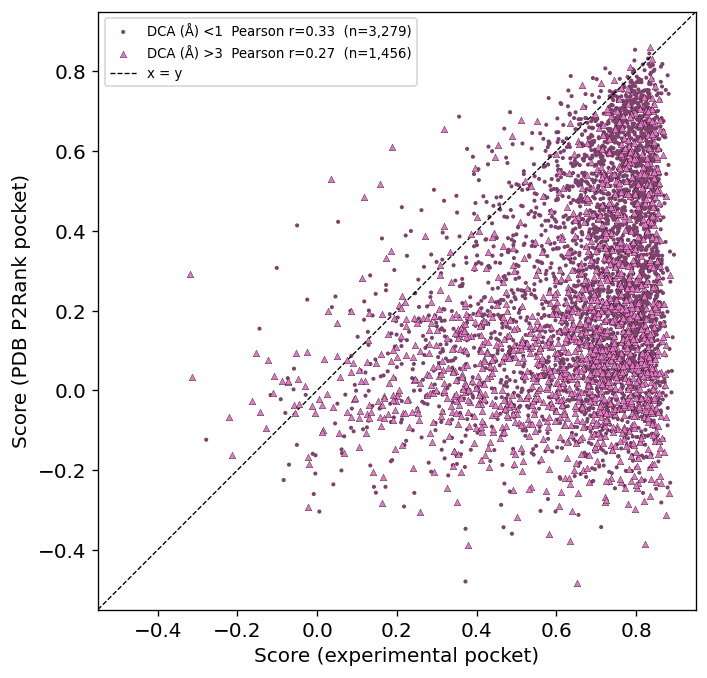

In [4]:
plot_metric_scatter(CONDITIONS[0], 'dca', good_thresh=1, bad_thresh=3);

PDB P2Rank — DCC (Å) within correct only (n=13,348)


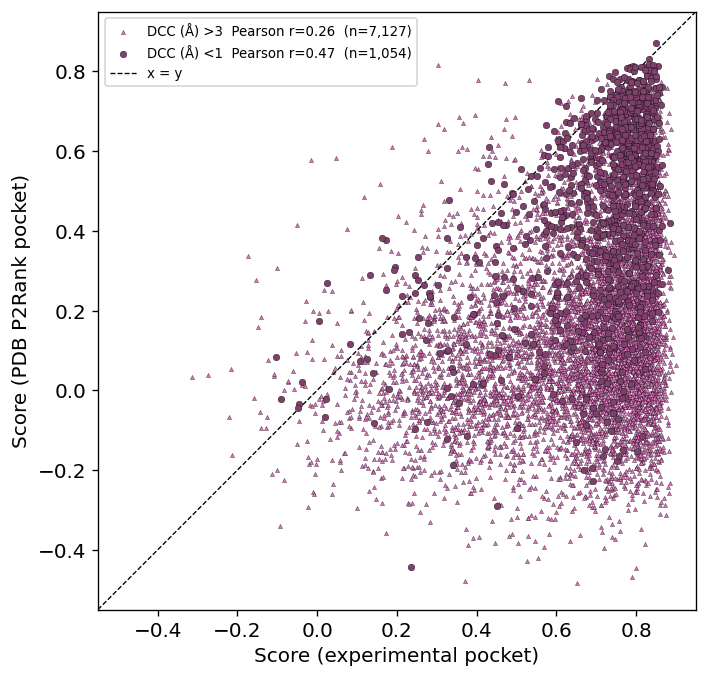

In [5]:
plot_metric_scatter(CONDITIONS[0], 'dcc', good_thresh=1, bad_thresh=3);

PDB P2Rank — Residue recall within correct only (n=13,348)


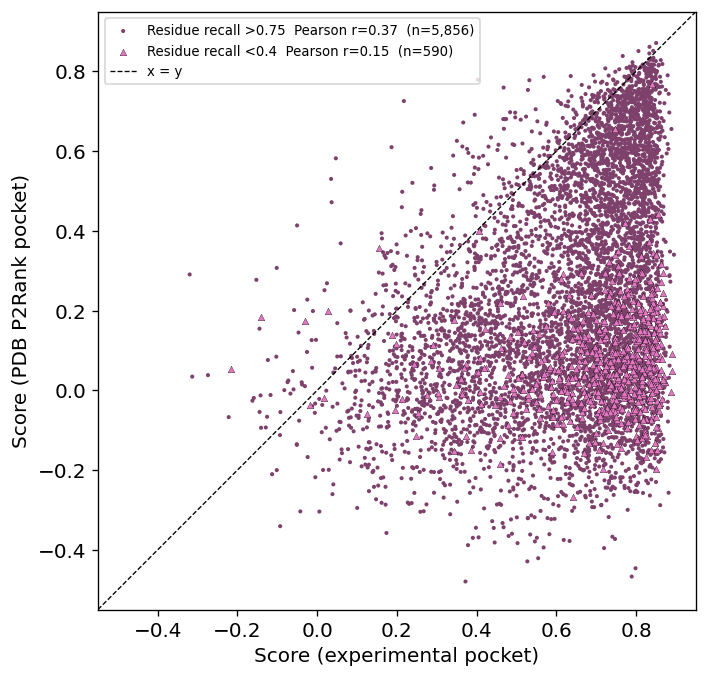

In [6]:
plot_metric_scatter(CONDITIONS[0], 'recall', good_thresh=0.75, bad_thresh=0.4);

PDB P2Rank — Residue Intersection over Union within correct only (n=13,348)


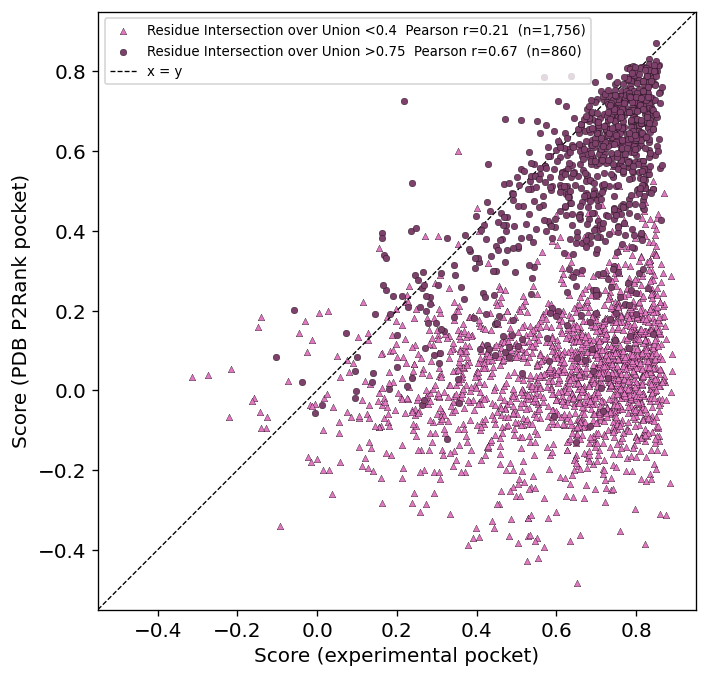

In [7]:
plot_metric_scatter(CONDITIONS[0], 'iou', good_thresh=0.75, bad_thresh=0.4);

## AFDB P2Rank — same default thresholds

AFDB P2Rank — DCA (Å) within correct only (n=8,353)


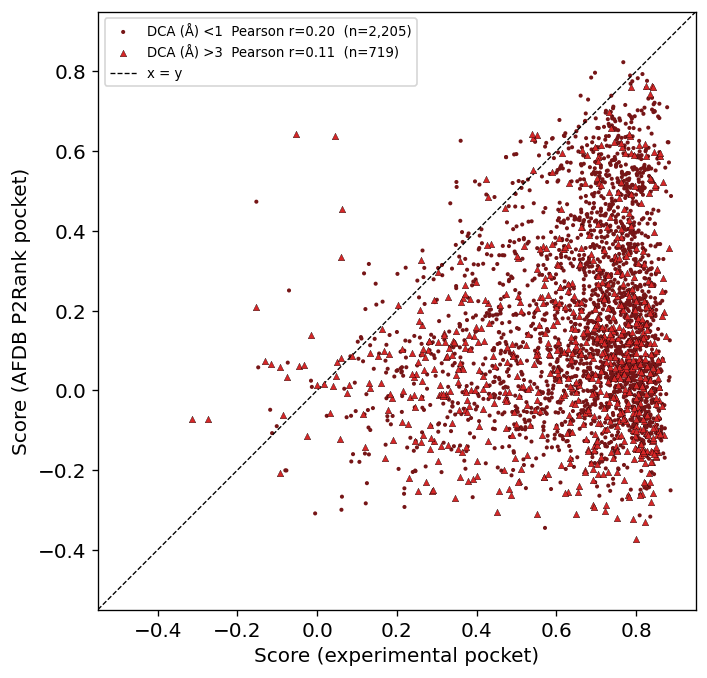

In [8]:
plot_metric_scatter(CONDITIONS[1], 'dca', good_thresh=1, bad_thresh=3);

AFDB P2Rank — DCC (Å) within correct only (n=8,353)


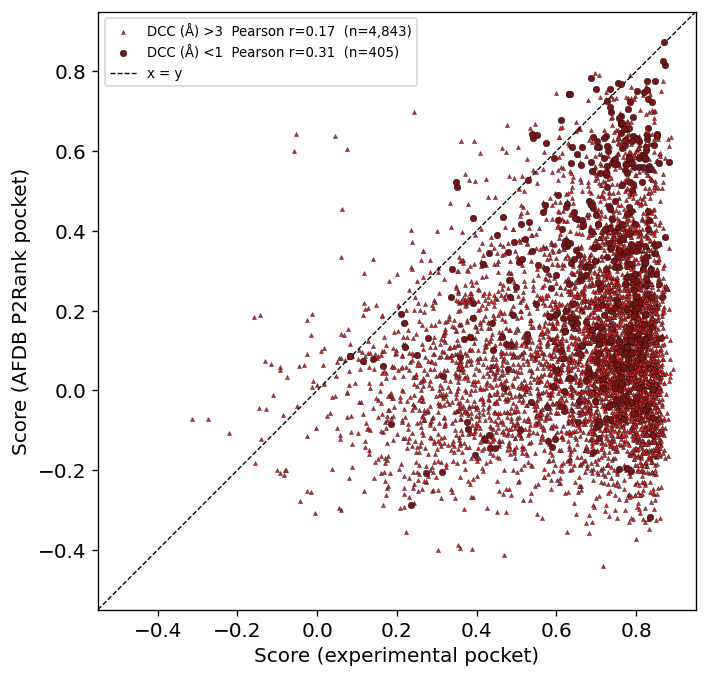

In [9]:
plot_metric_scatter(CONDITIONS[1], 'dcc', good_thresh=1, bad_thresh=3);

AFDB P2Rank — Residue recall within correct only (n=8,353)


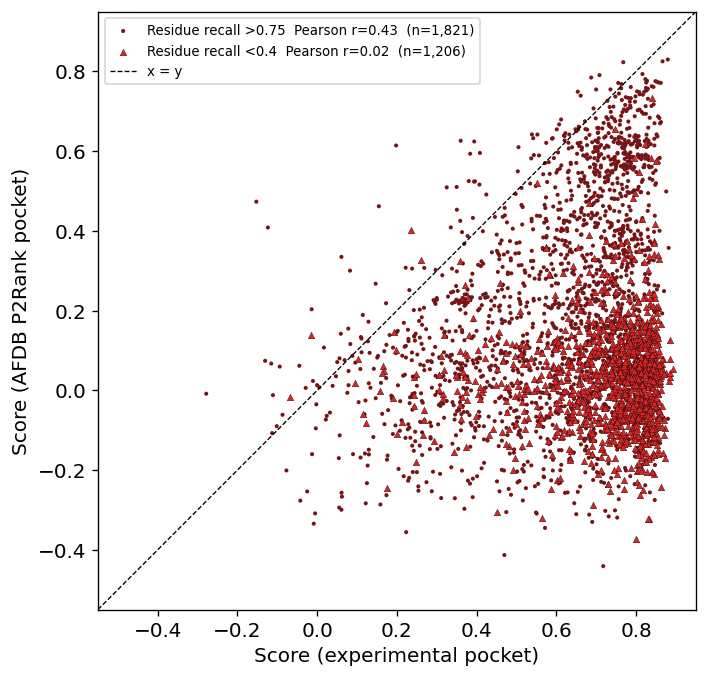

In [10]:
plot_metric_scatter(CONDITIONS[1], 'recall', good_thresh=0.75, bad_thresh=0.4);

AFDB P2Rank — Residue Intersection over Union within correct only (n=8,353)


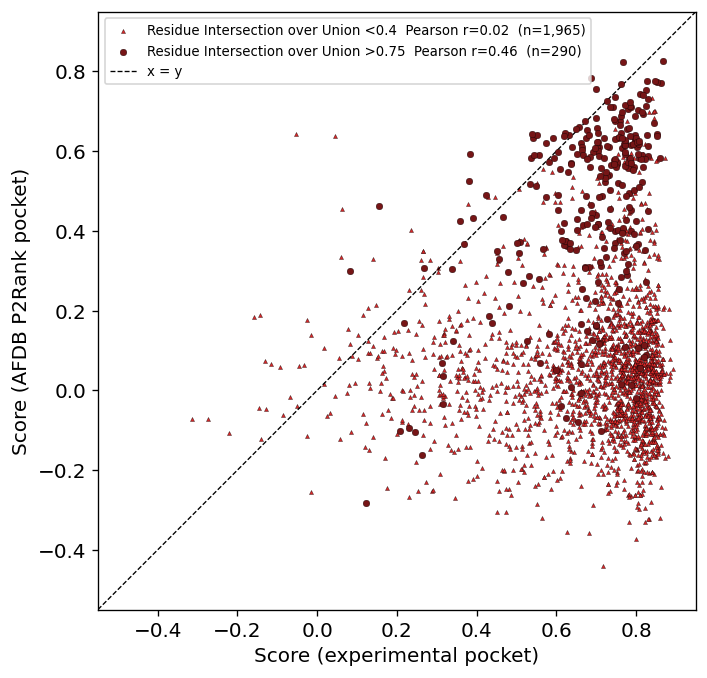

In [11]:
plot_metric_scatter(CONDITIONS[1], 'iou', good_thresh=0.75, bad_thresh=0.4);

## Threshold sensitivity

Same two plots, different numbers — DCA good threshold loosened from `<1` to `<2` (PDB), and
IoU thresholds loosened from `>0.9 / <0.5` to `>0.75 / <0.25` (PDB) — to see whether the picture
is threshold-sensitive or holds up either way.

PDB P2Rank — DCA (Å) within correct only (n=13,348)


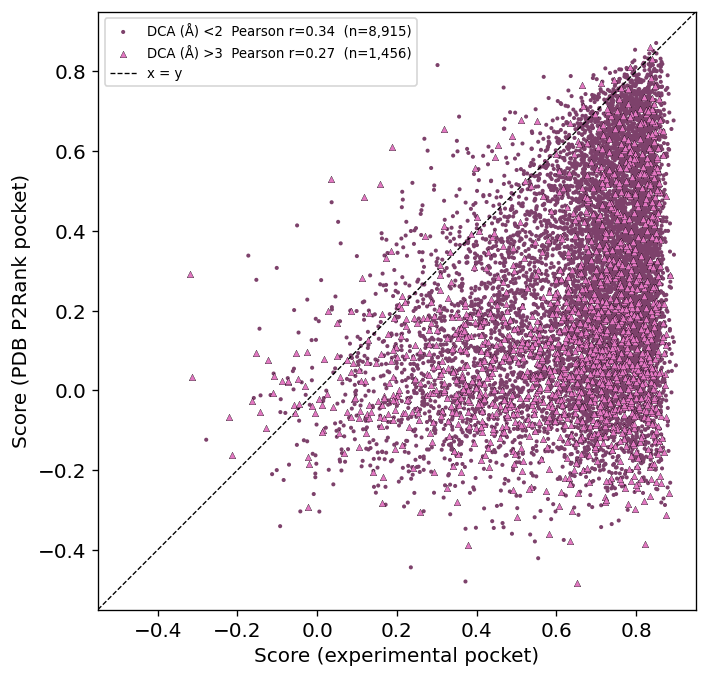

In [12]:
plot_metric_scatter(CONDITIONS[0], 'dca', good_thresh=2, bad_thresh=3);

PDB P2Rank — Residue Intersection over Union within correct only (n=13,348)


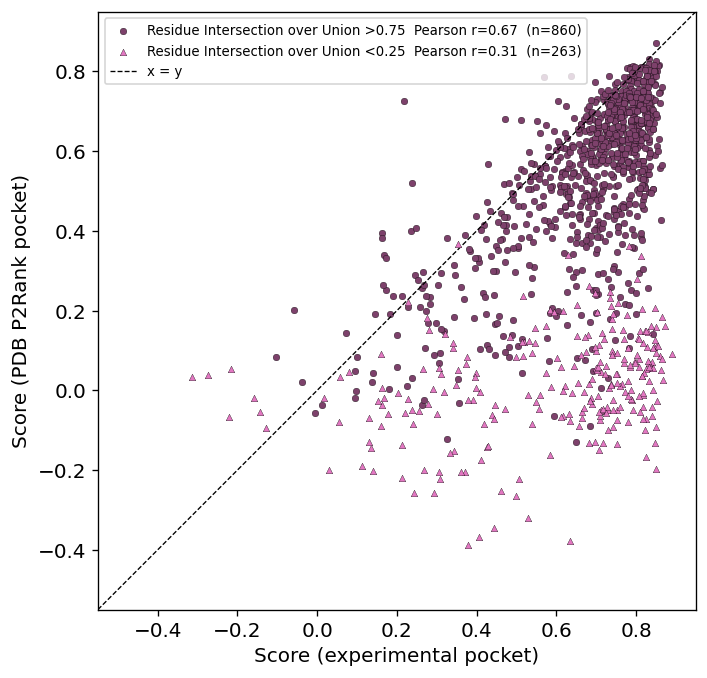

In [13]:
plot_metric_scatter(CONDITIONS[0], 'iou', good_thresh=0.75, bad_thresh=0.25);